**task 4 of Pandahat Adverserial Learning Path:** 

This task focuses on optimizing the CNN from Task 3 through data augmentation. A common issue in deep learning is overfitting, which occurs most often when the dataset is small. In this case, the model tends to memorize specific patterns in the training data, including noise and dataset-specific quirks, rather than learning generalizable features. This results in high training accuracy but poorer performance on unseen data.


Data augmentation helps address this issue by artificially increasing dataset diversity through the creation of modified versions of existing samples. This encourages the model to learn more robust patterns instead of memorizing individual examples, thereby improving generalization.


Some of the most common augmentation techniques include:


**Scaling**: helps the model handle variations in object size and position.

**Rotation**: useful when objects may appear at different angles.

**Flipping**: appropriate when orientation does not affect class meaning.

**Brightness and contrast adjustments**: introduce variation in lighting conditions.


The interaction between augmentation and labels depends on the task. In patch-based CNN classification, augmentation does not change the label, since each patch corresponds to a single class. However, in pixel-level prediction tasks such as semantic segmentation (e.g., DeepLabV3+), it is necessary to apply the same geometric transformations to both the input image and the corresponding label mask to preserve spatial alignment. Importantly, photometric transformations (such as brightness and contrast adjustments) **must NOT be applied to labels**, as each pixel represents a class value. Applying such transformations would corrupt the label information and lead to incorrect training signals.

# Convolutional Neural Network

Imports:

In [ ]:
import numpy as np
import os
import glob
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import f1_score
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
import seaborn as sns
import random


class mapping/id mapping:

In [ ]:
class_to_id = {
    "Water/Cloud": 0,
    "Bare Soil": 1,
    "Sparse Vegetation": 2,
    "Dense Vegetation": 3
}

Sample loader:

In [ ]:
base_dir = os.path.join(os.getcwd(), "..")
labels_path = os.path.join(base_dir, "labels")
samples_path = os.path.join(base_dir, "samples")

sample_files = sorted(glob.glob(os.path.join(samples_path, "*.tiff")))
label_files = sorted(glob.glob(os.path.join(labels_path,  "*.tiff")))
print(f"Found {len(sample_files)} samples, {len(label_files)} labels")

Found 614 samples, 614 labels
614
614


sample and label augmentation function:

In [14]:
def augment_pair(image_pil, label_pil):
    # Horizontal flip
    if random.random() < 0.5:
        image_pil = TF.hflip(image_pil)
        label_pil = TF.hflip(label_pil)

    # Vertical flip
    if random.random() < 0.5:
        image_pil = TF.vflip(image_pil)
        label_pil = TF.vflip(label_pil)

    # Rotate
    if random.random() < 0.5:
        angle = random.uniform(-30, 30)
        image_pil = TF.rotate(image_pil, angle, fill=0)
        label_pil = TF.rotate(label_pil, angle, fill=0)

    # Scale
    if random.random() < 0.5:
        scale = random.uniform(0.9, 1.1)
        translate_x = random.uniform(-0.1, 0.1) * 256
        translate_y = random.uniform(-0.1, 0.1) * 256
        image_pil = TF.affine(image_pil, angle=0, translate=[translate_x, translate_y], scale=scale, shear=0, fill=0)
        label_pil = TF.affine(label_pil, angle=0, translate=[translate_x, translate_y], scale=scale, shear=0, fill=0)
    
    # Brightness and contrast (doesn't apply to labels as that would corrupt them)
    if random.random() < 0.5:
        brightness_factor = random.uniform(0.7, 1.3)
        image_pil = TF.adjust_brightness(image_pil, brightness_factor)

    if random.random() < 0.5:
        contrast_factor = random.uniform(0.8, 1.2)
        image_pil = TF.adjust_contrast(image_pil, contrast_factor)

    return image_pil, label_pil




Extracting patches and assigning classes:

In [ ]:
PATCH_SIZE = 32
HALF = PATCH_SIZE // 2  
PATCHES_PER_IMAGE = 50   

def extract_patches_original(img_array, label_array, n_patches):
    ndvi = (label_array / 255.0) * 2 - 1
    print(f"ndvi shape: {ndvi.shape}, img shape: {img_array.shape}")
    H, W = img_array.shape[:2]
    rows = np.random.randint(HALF, H - HALF, size=n_patches)
    cols = np.random.randint(HALF, W - HALF, size=n_patches)
    patches = []
    for r, c in zip(rows, cols):
        patch = img_array[r-HALF:r+HALF, c-HALF:c+HALF, :]
        print(f"patch shape: {patch.shape}")  
        if patch.shape != (PATCH_SIZE, PATCH_SIZE, 3):
            continue
        ndvi_val = ndvi[r, c]
        if ndvi_val < 0:   
            veg_class = "Water/Cloud"
        elif ndvi_val < 0.2: 
            veg_class = "Bare Soil"
        elif ndvi_val < 0.5: 
            veg_class = "Sparse Vegetation"
        else:                
            veg_class = "Dense Vegetation"
        patches.append((patch, class_to_id[veg_class]))
    return patches

def extract_patches_augmented(img_array, label_array, n_patches):
    # takes the image and augments it to then extract patches from the result
    img_pil = Image.fromarray(img_array.astype(np.uint8))
    label_pil = Image.fromarray(label_array.astype(np.uint8))
    img_pil, label_pil = augment_pair(img_pil, label_pil)
    img_array = np.array(img_pil)
    label_array = np.array(label_pil)

    return extract_patches_original(img_array, label_array, n_patches)



Build dataset:

In [ ]:
train_files, test_files = train_test_split(list(zip(sample_files, label_files)),test_size=0.2, random_state=42)

print("Extracting patches...")

train_patches = []
for img_path, lbl_path in train_files:
    img   = np.array(Image.open(img_path).convert("RGB"))
    label = np.array(Image.open(lbl_path))
    if label.ndim == 3:
        label = label[:, :, 0]
    train_patches += extract_patches_original(img, label, PATCHES_PER_IMAGE)
    train_patches += extract_patches_augmented(img, label, PATCHES_PER_IMAGE)

# only originals for testing
test_patches = []
for img_path, lbl_path in test_files:
    img   = np.array(Image.open(img_path).convert("RGB"))
    label = np.array(Image.open(lbl_path))
    if label.ndim == 3:
        label = label[:, :, 0]
    test_patches += extract_patches_original(img, label, PATCHES_PER_IMAGE)

print(f"Collected: {len(train_patches) + len(test_patches)} patches")
print(f"Train patches: {len(train_patches)} | Test patches: {len(test_patches)}")


Extracting patches...
ndvi shape: (256, 256), img shape: (256, 256, 3)
patch shape: (32, 32, 3)
patch shape: (32, 32, 3)
patch shape: (32, 32, 3)
patch shape: (32, 32, 3)
patch shape: (32, 32, 3)
patch shape: (32, 32, 3)
patch shape: (32, 32, 3)
patch shape: (32, 32, 3)
patch shape: (32, 32, 3)
patch shape: (32, 32, 3)
patch shape: (32, 32, 3)
patch shape: (32, 32, 3)
patch shape: (32, 32, 3)
patch shape: (32, 32, 3)
patch shape: (32, 32, 3)
patch shape: (32, 32, 3)
patch shape: (32, 32, 3)
patch shape: (32, 32, 3)
patch shape: (32, 32, 3)
patch shape: (32, 32, 3)
patch shape: (32, 32, 3)
patch shape: (32, 32, 3)
patch shape: (32, 32, 3)
patch shape: (32, 32, 3)
patch shape: (32, 32, 3)
patch shape: (32, 32, 3)
patch shape: (32, 32, 3)
patch shape: (32, 32, 3)
patch shape: (32, 32, 3)
patch shape: (32, 32, 3)
patch shape: (32, 32, 3)
patch shape: (32, 32, 3)
patch shape: (32, 32, 3)
patch shape: (32, 32, 3)
patch shape: (32, 32, 3)
patch shape: (32, 32, 3)
patch shape: (32, 32, 3)
patc

PyTorch Dataset, test split and DataLoader:

In [ ]:
class PatchDataset(Dataset):
    def __init__(self, patches):
        self.patches = patches

    def __len__(self):
        return len(self.patches)

    def __getitem__(self, idx):
        patch, label = self.patches[idx]
        x = torch.tensor(patch / 255.0, dtype=torch.float32).permute(2, 0, 1)
        y = torch.tensor(label, dtype=torch.long)
        return x, y


train_dataset = PatchDataset(train_patches)
test_dataset  = PatchDataset(test_patches)

# WARNING: ADJUST TO YOUR SPECS!

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

print(f"Train: {len(train_dataset)} | Test: {len(test_dataset)}")


Train: 49100 | Test: 6150


CNN Model:

In [ ]:
class VegetationCNN(nn.Module):
    def __init__(self, num_classes=4):
        super(VegetationCNN, self).__init__()

        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),   
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),  
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),                              
            nn.Dropout2d(p=0.1)
        )

       
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),  
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1), 
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),                              
            nn.Dropout2d(p=0.1)
        )

       
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1), 
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),                             
            nn.Dropout2d(p=0.1)
        )

        self.classifier = nn.Sequential(
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(p=0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.block1(x)           
        x = self.block2(x)       
        x = self.block3(x)           
        x = x.view(x.size(0), -1) 
        x = self.classifier(x)      
        return x

Device selection and base config:

In [34]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nUsing device: {device}")

model = VegetationCNN(num_classes=4).to(device)
criterion = nn.CrossEntropyLoss(weight=torch.tensor([3.0, 1.5, 1.0, 1.0], dtype=torch.float32).to(device))
optimizer = optim.Adam(model.parameters(), lr=0.001)

train_losses = []
val_losses = []

EPOCHS = 20


Using device: cpu


Experimentation:

In [ ]:
experiments = [
    {"lr": 0.01, "optimizer": "SGD", "dropout": 0.1, "note": "baseline"},
    {"lr": 0.001, "optimizer": "SGD", "dropout": 0.1, "note": "lower lr"},
    {"lr": 0.001, "optimizer": "Adam", "dropout": 0.1, "note": "Adam optimizer"},
    {"lr": 0.001, "optimizer": "Adam", "dropout": 0.3, "note": "higher dropout"},
    {"lr": 0.0001, "optimizer": "Adam", "dropout": 0.3, "note": "very low lr"},
]

experiment_results = []

for exp in experiments:
    exp_model = VegetationCNN(num_classes=4).to(device)

    if exp["optimizer"] == "SGD":
        exp_optimizer = optim.SGD(
            exp_model.parameters(),
            lr=exp["lr"], momentum=0.9, weight_decay=1e-4
        )
    elif exp["optimizer"] == "Adam":
        exp_optimizer = optim.Adam(
            exp_model.parameters(),
            lr=exp["lr"], weight_decay=1e-4
        )

    for epoch in range(50):
        exp_model.train()
        for i, (X_batch, y_batch) in enumerate(train_loader):
            # if i > 20:
            #     break
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            exp_optimizer.zero_grad()
            outputs = exp_model(X_batch)
            loss    = criterion(outputs, y_batch)
            loss.backward()
            exp_optimizer.step()

    exp_model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            outputs  = exp_model(X_batch.to(device))
            preds    = outputs.argmax(dim=1)
            correct += (preds == y_batch.to(device)).sum().item()
            total   += y_batch.size(0)

    val_acc = correct / total
    experiment_results.append({**exp, "val_acc": val_acc})
    print(f"Config: lr={exp['lr']} | opt={exp['optimizer']} | "
          f"dropout={exp['dropout']} | note={exp['note']} | "
          f"val_acc={val_acc:.4f}")

print("\n" + "="*75)
print("HYPERPARAMETER EXPERIMENT RESULTS (50 epochs each)")
print("="*75)
print(f"{'Note':<25} {'LR':>8} {'Optimizer':>10} {'Dropout':>8} {'Val Acc':>10}")
print("-"*75)
for r in experiment_results:
    print(f"{r['note']:<25} {r['lr']:>8} {r['optimizer']:>10} "
          f"{r['dropout']:>8} {r['val_acc']:>10.4f}")
print("="*75)
print("\nBest config selected for full training above based on these results.")

Config: lr=0.01 | opt=SGD | dropout=0.1 | note=baseline | val_acc=0.2104
Config: lr=0.001 | opt=SGD | dropout=0.1 | note=lower lr | val_acc=0.5802
Config: lr=0.001 | opt=Adam | dropout=0.1 | note=Adam optimizer | val_acc=0.4815
Config: lr=0.001 | opt=Adam | dropout=0.3 | note=higher dropout | val_acc=0.5467
Config: lr=0.0001 | opt=Adam | dropout=0.3 | note=very low lr | val_acc=0.5016

HYPERPARAMETER EXPERIMENT RESULTS (5 epochs each)
Note                            LR  Optimizer  Dropout    Val Acc
---------------------------------------------------------------------------
baseline                      0.01        SGD      0.1     0.2104
lower lr                     0.001        SGD      0.1     0.5802
Adam optimizer               0.001       Adam      0.1     0.4815
higher dropout               0.001       Adam      0.3     0.5467
very low lr                 0.0001       Adam      0.3     0.5016

Best config selected for full training above based on these results.


New optimizer config based on experimentation:

In [ ]:
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

Training (This takes some time):

In [38]:
print("\nTraining...")

for epoch in range(EPOCHS):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = outputs.argmax(dim=1)
        correct += (preds == y_batch).sum().item()
        total += y_batch.size(0)

    train_acc = correct / total
    avg_train_loss = total_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    model.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            val_loss += loss.item()
            preds = outputs.argmax(dim=1)
            val_correct += (preds == y_batch).sum().item()
            val_total += y_batch.size(0)
    
    avg_val_loss = val_loss / len(test_loader)
    val_acc = val_correct / val_total
    val_losses.append(avg_val_loss)

    print(f"Epoch {epoch+1:02d}/{EPOCHS} | Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.4f}")



Training...
Epoch 01/20 | Train Loss: 0.8841 | Train Acc: 0.6201 | Val Loss: 0.7460 | Val Acc: 0.6971
Epoch 02/20 | Train Loss: 0.7252 | Train Acc: 0.6995 | Val Loss: 0.6854 | Val Acc: 0.7380
Epoch 03/20 | Train Loss: 0.6704 | Train Acc: 0.7229 | Val Loss: 0.7952 | Val Acc: 0.6855
Epoch 04/20 | Train Loss: 0.6344 | Train Acc: 0.7397 | Val Loss: 0.6809 | Val Acc: 0.7197
Epoch 05/20 | Train Loss: 0.6065 | Train Acc: 0.7529 | Val Loss: 0.6107 | Val Acc: 0.7486
Epoch 06/20 | Train Loss: 0.5830 | Train Acc: 0.7604 | Val Loss: 0.7613 | Val Acc: 0.6940
Epoch 07/20 | Train Loss: 0.5618 | Train Acc: 0.7728 | Val Loss: 0.6259 | Val Acc: 0.7504
Epoch 08/20 | Train Loss: 0.5448 | Train Acc: 0.7767 | Val Loss: 0.5893 | Val Acc: 0.7611
Epoch 09/20 | Train Loss: 0.5311 | Train Acc: 0.7832 | Val Loss: 0.5743 | Val Acc: 0.7875
Epoch 10/20 | Train Loss: 0.5191 | Train Acc: 0.7897 | Val Loss: 0.5574 | Val Acc: 0.7782
Epoch 11/20 | Train Loss: 0.5026 | Train Acc: 0.7960 | Val Loss: 0.6188 | Val Acc: 0.77

Evaluation:

In [39]:
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)
        preds = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y_batch.numpy())

accuracy = accuracy_score(all_labels, all_preds)
print(f"\nTest Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=['Water/Cloud', 'Bare Soil', 'Sparse Veg', 'Dense Veg']))



Test Accuracy: 0.7935

Classification Report:
              precision    recall  f1-score   support

 Water/Cloud       0.60      0.80      0.68       356
   Bare Soil       0.73      0.68      0.70      1234
  Sparse Veg       0.81      0.78      0.79      2525
   Dense Veg       0.85      0.88      0.87      2035

    accuracy                           0.79      6150
   macro avg       0.75      0.78      0.76      6150
weighted avg       0.80      0.79      0.79      6150



Confusion Matrix Visualization:

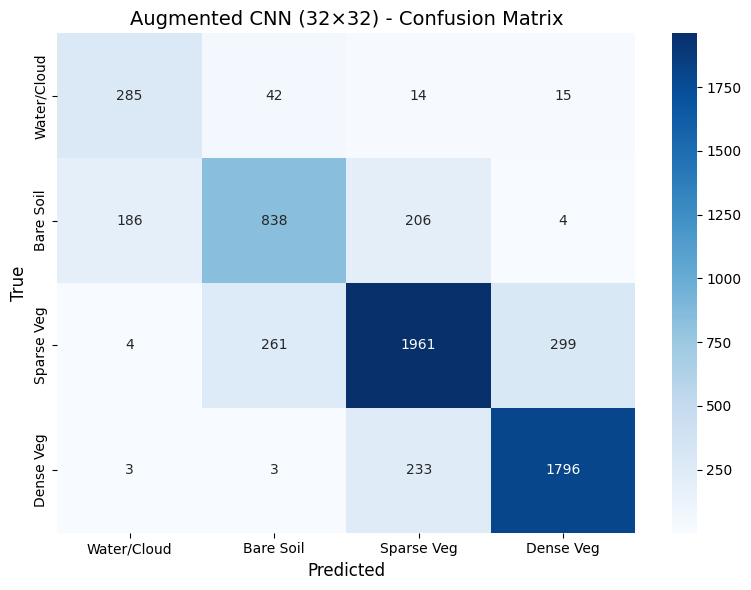

In [40]:
class_names = ['Water/Cloud', 'Bare Soil', 'Sparse Veg', 'Dense Veg']
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('True', fontsize=12)
plt.title('Augmented CNN (32×32) - Confusion Matrix', fontsize=14)
plt.tight_layout()
plt.savefig('augmented_cnn_confusion_matrix.png', dpi=150)
plt.show()

Loss Curves Visualization:

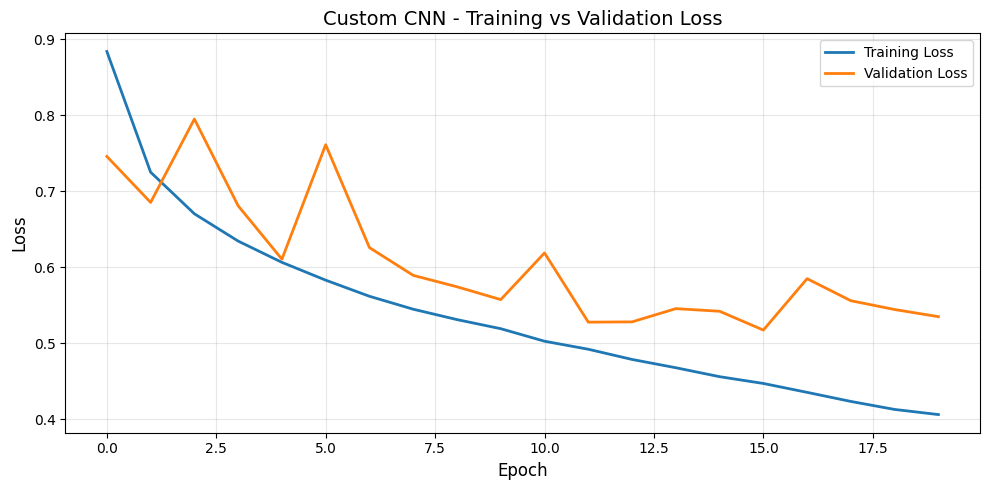

Length of train_losses: 20
Length of val_losses: 20
First 5 train losses: [0.8841304533804456, 0.7252011587067196, 0.6704085130089273, 0.6344497133977711, 0.6064627060744291]
Last 5 train losses: [0.44698960351524875, 0.4352577457126851, 0.42329788906499743, 0.4127561832622935, 0.40601853048428893]
First 5 val losses: [0.7459668765977486, 0.685365322631659, 0.7951833415277225, 0.6809183773920708, 0.6106558420608953]
Last 5 val losses: [0.5172726276916327, 0.5849563665303987, 0.5559177569200083, 0.5443241567034083, 0.5349288410747174]
Final Training Loss: 0.4060
Final Validation Loss: 0.5349

   Consider: more regularization, dropout, or early stopping

Loss curves saved to: cnn_loss_curves.png


In [42]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss', linewidth=2)
plt.plot(val_losses, label='Validation Loss', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Custom CNN - Training vs Validation Loss', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('cnn_loss_curves.png', dpi=150)
plt.show()

print(f"Length of train_losses: {len(train_losses)}")
print(f"Length of val_losses: {len(val_losses)}")
print(f"First 5 train losses: {train_losses[:5]}")
print(f"Last 5 train losses: {train_losses[-5:]}")
print(f"First 5 val losses: {val_losses[:5]}")
print(f"Last 5 val losses: {val_losses[-5:]}")
print(f"Final Training Loss: {train_losses[-1]:.4f}")
print(f"Final Validation Loss: {val_losses[-1]:.4f}")

# Check for overfitting/underfitting
if val_losses[-1] > train_losses[-1] * 1.2:
    print("\n Warning: Possible overfitting (validation loss > training loss by 20%)")
    print("   Consider: more regularization, dropout, or early stopping")
elif val_losses[-1] < train_losses[-1] * 0.8:
    print("\nWarning: Possible underfitting (validation loss < training loss)")
    print("   Consider: more epochs or a more complex model")
else:
    print("\nTraining behavior looks good - losses are balanced")

print(f"\nLoss curves saved to: cnn_loss_curves.png")

Prediction Visualizations:

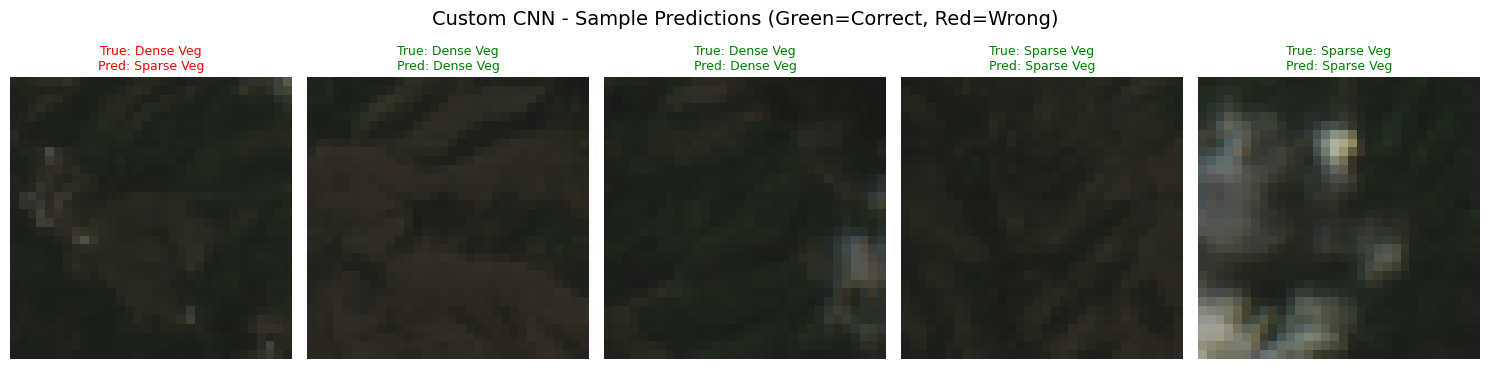


Prediction Details:
Sample 1: True=Dense Veg, Pred=Sparse Veg [ WRONG]
Sample 2: True=Dense Veg, Pred=Dense Veg [ CORRECT]
Sample 3: True=Dense Veg, Pred=Dense Veg [ CORRECT]
Sample 4: True=Sparse Veg, Pred=Sparse Veg [ CORRECT]
Sample 5: True=Sparse Veg, Pred=Sparse Veg [ CORRECT]

Accuracy on these 5 samples: 4/5 = 80%

Predictions visualization saved to: cnn_predictions.png


In [43]:
model.eval()
sample_images = []
sample_labels = []
sample_preds = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)
        preds = outputs.argmax(dim=1)
        
        for i in range(min(5, len(X_batch))):
            sample_images.append(X_batch[i].cpu())
            sample_labels.append(y_batch[i].item())
            sample_preds.append(preds[i].item())
        
        if len(sample_images) >= 5:
            break

class_names = ['Water/Cloud', 'Bare Soil', 'Sparse Veg', 'Dense Veg']


fig, axes = plt.subplots(1, 5, figsize=(15, 4))

for i, (img, true_label, pred_label) in enumerate(zip(sample_images[:5], sample_labels[:5], sample_preds[:5])):
    img_display = img.permute(1, 2, 0).numpy()
    
    axes[i].imshow(img_display)
    color = 'green' if true_label == pred_label else 'red'
    axes[i].set_title(f'True: {class_names[true_label]}\nPred: {class_names[pred_label]}', color=color, fontsize=9)
    axes[i].axis('off')

plt.suptitle('Custom CNN - Sample Predictions (Green=Correct, Red=Wrong)', fontsize=14)
plt.tight_layout()
plt.savefig('cnn_predictions.png', dpi=150)
plt.show()

print("\nPrediction Details:")
correct_count = 0
for i, (true_label, pred_label) in enumerate(zip(sample_labels[:5], sample_preds[:5])):
    status = " CORRECT" if true_label == pred_label else " WRONG"
    if true_label == pred_label:
        correct_count += 1
    print(f"Sample {i+1}: True={class_names[true_label]}, Pred={class_names[pred_label]} [{status}]")

print(f"\nAccuracy on these 5 samples: {correct_count}/5 = {correct_count/5*100:.0f}%")
print(f"\nPredictions visualization saved to: cnn_predictions.png")

# Comparison

In [ ]:
svm_scores = {
    "Water/Cloud": 0.45,
    "Bare Soil": 0.61,
    "Sparse Veg": 0.76,
    "Dense Veg": 0.87,
    "Overall Acc": 0.75
}

cnn_scores = {
    "Water/Cloud": 0.53,   
    "Bare Soil": 0.75,  
    "Sparse Veg": 0.83,   
    "Dense Veg": 0.88,   
    "Overall Acc": 0.8174  
}

print("\n" + "="*65)
print("FULL MODEL COMPARISON (F1-score per class)")
print("="*65)
print(f"{'Class':<20} {'SVM':>10} {'Custom CNN':>12} {'DeepLabV3+':>12}")
print("-"*65)

classes = ['Water/Cloud', 'Bare Soil', 'Sparse Veg', 'Dense Veg']
for i, cls in enumerate(classes):
    print(f"{cls:<20} {svm_scores[cls]:>10.2f} {cnn_scores[cls]:>12.2f} {deeplab_f1[i]:>12.3f}")

print(f"{'Overall Acc':<20} {svm_scores['Overall Acc']:>10.2f} "f"{cnn_scores['Overall Acc']:>12.3f} {deep_accuracy:>12.3f}")
print("="*65)


FULL MODEL COMPARISON (F1-score per class)
Class                       SVM   Custom CNN   DeepLabV3+
-----------------------------------------------------------------
Water/Cloud                0.45         0.53        0.690
Bare Soil                  0.61         0.75        0.689
Sparse Veg                 0.76         0.83        0.747
Dense Veg                  0.87         0.88        0.810
Overall Acc                0.75        0.817        0.753


**ANALYSIS**:

**Original findings, 10 epochs on DeepLabV3+:**
The custom CNN, was the most accurate model, with an overall accuracy of 81%, outperforming both the SVM baseline (75%) and the pre-trained DeepLabv3+ (74%). The CNN's superior performance can be attributed to its patch-based approach (7×7 patches) which captures local spatial patterns effectively, and its training from scratch on 20 epochs specifically for this dataset. DeepLabV3+, while pre-trained on ImageNet, was limited to 10 epochs due to computational constraints and may benefit from additional fine-tuning. Notably, all models performed best on Dense Vegetation and struggled most with Water/Cloud classification, suggesting this class may benefit from additional training samples or spectral bands.

**Updated findings, 20 epochs on DeepLabV3+ (same number as CNN):**
Following the initial training, DeepLabV3+ was further trained with 20 epochs under the same conditions to ensure a fair comparison. Under extended training, performance improved slightly, to 75.8%, compared to the original 74%. However the custom CNN maintained its 81% accuracy, suggesting that the observed gap is not soley due to insufficient training of DeepLabV3+. To verify implementation stability, DeepLabV3+ was evaluated on both Apple Silicon (M4 MacBook Pro) and an NVIDIA GPU (5070 ti). Results were relatively consistent across hardware (0.754 vs 0.758), indicating negligible variance due to computational platform.